## Environment Setup

In [1]:
"""
Initializes required libraries, configures output directories, and defines 
custom wrappers for mitigating clinical data imbalances during model training.
"""
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from collections import Counter
import warnings
import joblib

warnings.filterwarnings('ignore')

# Feature Engineering
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.feature_extraction import DictVectorizer

# Modeling & Tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import optuna

# Evaluation & XAI
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Initialize output directories
os.makedirs("../images", exist_ok=True)
os.makedirs("../data/results", exist_ok=True)

class XGBWithSampleWeight(XGBClassifier):
    """
    Custom wrapper for XGBClassifier to dynamically inject 
    balanced sample weights during the fitting process.
    """
    def fit(self, X, y, **kwargs):
        from sklearn.utils.class_weight import compute_sample_weight
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# Configure global plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Data Acquisition & Filtering

In [2]:
"""
Ingests the ClinVar variation summary, filters for relevant single nucleotide 
variants (SNVs), and partitions the data into a training set (known clinical 
significance) and a prediction set (Variants of Uncertain Significance).
"""
print("Loading dataset...")
# Raw data source: https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/
df_raw = pd.read_csv("../data/variant_summary.txt.gz", sep='\t', low_memory=False)

# Standardize nomenclature and apply genomic filters (GRCh38 assembly, SNVs only)
df_raw.rename(columns={'ClinSigSimple': 'Label'}, inplace=True)
df_filtered = df_raw[(df_raw['Assembly'] == 'GRCh38') & 
                     (df_raw['Type'] == 'single nucleotide variant')]

# Isolate Variants of Uncertain Significance (VUS) for pipeline deployment
vus_condition = df_filtered['ClinicalSignificance'].isin(['Uncertain significance'])
df_uncertain = df_filtered[vus_condition].copy()

# Retain variants with established clinical consensus (Pathogenic/Benign) for training
known_condition = df_filtered['ClinicalSignificance'].isin(['Pathogenic', 'Benign'])
df_known = df_filtered[known_condition].copy()

relevant_cols = [
    'VariationID', 'GeneSymbol', 'Type', 'ClinicalSignificance', 
    'Label', 'Chromosome', 'Start', 'ReferenceAlleleVCF', 'AlternateAlleleVCF'
]
df_known = df_known[relevant_cols].dropna().reset_index(drop=True)
df_uncertain = df_uncertain[relevant_cols].dropna().reset_index(drop=True)

def remove_ambiguous_entries(dataframe):
    """Drops records containing invalid or ambiguous nucleotide bases."""
    valid_bases = {'A', 'T', 'G', 'C'}
    mask = (
        dataframe['ReferenceAlleleVCF'].isin(valid_bases) & 
        dataframe['AlternateAlleleVCF'].isin(valid_bases)
    )
    return dataframe[mask].dropna(subset=['ReferenceAlleleVCF', 'AlternateAlleleVCF'])

df_known = remove_ambiguous_entries(df_known)
df_uncertain = remove_ambiguous_entries(df_uncertain)

print(f"Training set shape (Known): {df_known.shape}")
print(f"Prediction set shape (VUS): {df_uncertain.shape}")

Loading dataset...
Training set shape (Known): (261066, 9)
Prediction set shape (VUS): (1723243, 9)


## Genomic Feature Extraction

In [3]:
"""
Computes k-mer frequencies from reference and alternate alleles and applies 
a unified Label Encoding strategy across all datasets to prevent mapping divergence.
"""
print("Extracting k-mer features...")

def get_kmers(sequence, k=3):
    """Generates all k-length contiguous substrings from a given nucleotide sequence."""
    return [sequence[i:i+k] for i in range(len(sequence)-k+1)] if len(sequence) >= k else []

def extract_kmer_features(ref, alt):
    """Calculates frequency distributions for mono-, di-, and tri-nucleotide k-mers."""
    features = {}
    for k in [1, 2, 3]:  
        ref_kmers = Counter(get_kmers(ref.upper(), k))
        alt_kmers = Counter(get_kmers(alt.upper(), k))
        for kmer in set(ref_kmers) | set(alt_kmers):
            features[f'ref_k{k}_{kmer}'] = ref_kmers.get(kmer, 0)
            features[f'alt_k{k}_{kmer}'] = alt_kmers.get(kmer, 0)
    return features

def apply_kmers(dataframe):
    """Vectorizes the extracted k-mer dictionaries into the primary dataframe."""
    kmer_dicts = dataframe.apply(lambda row: extract_kmer_features(
        str(row['ReferenceAlleleVCF']), str(row['AlternateAlleleVCF'])
    ), axis=1)
    
    vectorizer = DictVectorizer(sparse=False)
    kmer_matrix = vectorizer.fit_transform(kmer_dicts)
    df_kmer = pd.DataFrame(kmer_matrix, columns=vectorizer.get_feature_names_out())
    return pd.concat([dataframe.reset_index(drop=True), df_kmer], axis=1)

df_known_feat = apply_kmers(df_known)
df_uncertain_feat = apply_kmers(df_uncertain)

# Cardinality reduction: Restrict categorical space to top 50 highly mutated genes
top_genes = df_known_feat['GeneSymbol'].value_counts().nlargest(50).index
df_known_feat['GeneSymbol'] = df_known_feat['GeneSymbol'].apply(lambda x: x if x in top_genes else 'Other')
df_uncertain_feat['GeneSymbol'] = df_uncertain_feat['GeneSymbol'].apply(lambda x: x if x in top_genes else 'Other')

print("Applying universal Label Encoding...")
label_cols = ['GeneSymbol', 'Type', 'Chromosome', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
le_dict = {}

for col in label_cols:
    le = LabelEncoder()
    # Fit encoder on the union of datasets to maintain consistent integer mapping
    all_categories = pd.concat([df_known_feat[col], df_uncertain_feat[col]])
    le.fit(all_categories)
    
    df_known_feat[col] = le.transform(df_known_feat[col])
    df_uncertain_feat[col] = le.transform(df_uncertain_feat[col])
    le_dict[col] = le

Extracting k-mer features...
Applying universal Label Encoding...


## Exploratory Data Analysis (EDA)

Generating EDA plots...


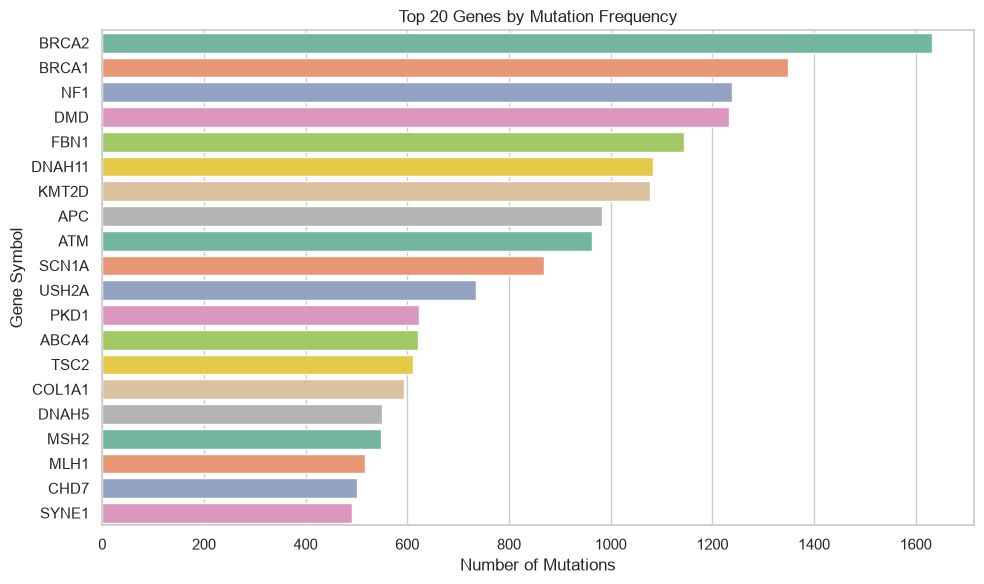

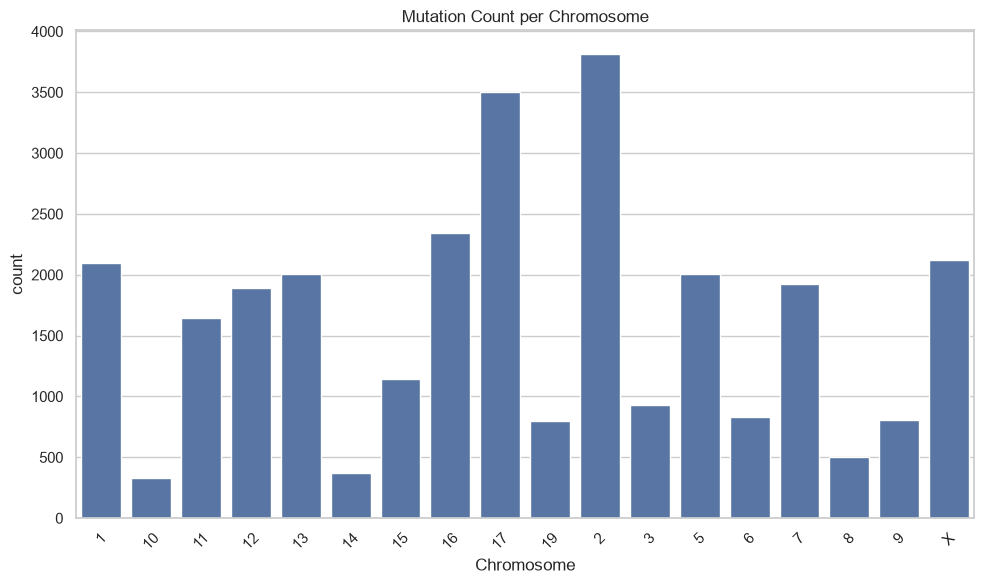

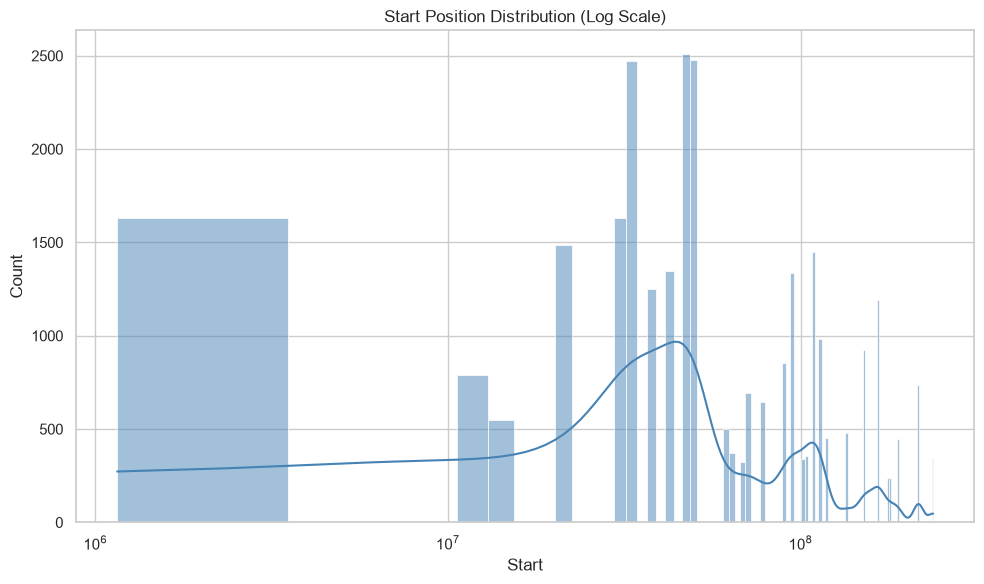

In [4]:
"""
Generates analytical visualizations of mutation distributions across genomic 
coordinates and exports high-resolution assets to the images directory.
"""
print("Generating EDA plots...")

# Temporarily reverse label encoding for interpretable plotting
df_plot = df_known_feat.copy()
for col in label_cols:
    df_plot[col] = le_dict[col].inverse_transform(df_plot[col])
df_plot_filtered = df_plot[df_plot['GeneSymbol'] != 'Other']

# Top 20 Mutated Genes
plt.figure(figsize=(10, 6))
top_genes_plot = df_plot_filtered['GeneSymbol'].value_counts().head(20)
sns.barplot(y=top_genes_plot.index, x=top_genes_plot.values, palette="Set2")
plt.title("Top 20 Genes by Mutation Frequency")
plt.xlabel("Number of Mutations")
plt.ylabel("Gene Symbol")
plt.tight_layout()
plt.savefig("../images/top_20_genes.png", dpi=300)
plt.show()

# Chromosome Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x="Chromosome", data=df_plot_filtered, 
              order=sorted(df_plot_filtered['Chromosome'].dropna().unique()))
plt.title("Mutation Count per Chromosome")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/mutation_dist.png", dpi=300)
plt.show()

# Start Position Density
plt.figure(figsize=(10, 6))
sns.histplot(df_plot_filtered['Start'].dropna(), bins=100, kde=True, color="steelblue")
plt.xscale("log")
plt.title("Start Position Distribution (Log Scale)")
plt.tight_layout()
plt.savefig("../images/start_position_dist.png", dpi=300)
plt.show()

## Interaction Features & Splitting

In [5]:
"""
Engineers second-degree polynomial interaction terms for encoded features 
and isolates the target variable while verifying the absence of data leakage.
"""
print("Generating interaction terms...")

def implement_interaction_features(dataframe):
    """Calculates pairwise polynomial interactions for numerical attributes, excluding IDs."""
    exclude_from_poly = ['VariationID', 'ClinicalSignificance', 'Label']
    
    numeric_input = dataframe.select_dtypes(include=['int32', 'int64', 'float64'])
    numeric_input = numeric_input.drop(columns=[c for c in exclude_from_poly if c in numeric_input.columns], errors='ignore')
    
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    interaction_matrix = poly.fit_transform(numeric_input)
    interaction_names = poly.get_feature_names_out(numeric_input.columns)
    
    df_interactions = pd.DataFrame(interaction_matrix, columns=interaction_names, index=dataframe.index)
    df_final = pd.concat([dataframe, df_interactions], axis=1)
    return df_final.loc[:, ~df_final.columns.duplicated()]

df_known_final = implement_interaction_features(df_known_feat)
df_uncertain_final = implement_interaction_features(df_uncertain_feat)

# Target separation and final leakage verification
leaking_cols = [col for col in df_known_final.columns if 'Label' in col]
X_known = df_known_final.drop(columns=['ClinicalSignificance', 'VariationID'] + leaking_cols)
y_known = df_known_final['Label']

X_vus = df_uncertain_final.drop(columns=['ClinicalSignificance', 'VariationID'] + leaking_cols)
vus_variation_ids = df_uncertain_final['VariationID']

# Generate stratified train/test partitions
X_train, X_test, y_train, y_test = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42, stratify=y_known
)
print(f"Final training feature matrix shape: {X_train.shape}")

Generating interaction terms...
Final training feature matrix shape: (208852, 105)


## Optuna Tuning & Model Training

In [6]:
"""
Executes Bayesian hyperparameter tuning using Optuna to optimize the 
EctremeGradientBoosting objective function across Stratified 3-Fold CV.
"""
def xgb_objective(trial):
    """Defines the hyperparameter search space for GPU-accelerated XGBoost."""
    model = XGBWithSampleWeight(
        tree_method='hist',
        device='cuda',  # Forces computations to the GPU
        n_estimators=trial.suggest_int('n_estimators', 100, 500, step=100),
        max_depth=trial.suggest_int('max_depth', 5, 15, step=2),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 1.0),
        max_bin=trial.suggest_categorical('max_bin', [64, 128, 255]),
        random_state=42,
        eval_metric='logloss'
    )
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean()

print("Initiating Optuna Hyperparameter Tuning...")
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0)
study = optuna.create_study(direction='maximize', pruner=pruner)
study.optimize(xgb_objective, n_trials=30)

print(f"Optimal Hyperparameters: {study.best_params}")

print("Training final optimized model...")
final_params = study.best_params.copy()
final_params.update({'tree_method': 'hist', 'device': 'cuda', 'random_state': 42})

best_xgb = XGBWithSampleWeight(**final_params)
best_xgb.fit(X_train, y_train)

# Serialize the optimal model weights
joblib.dump(best_xgb, "../data/opt_xgb_model.pkl")

[I 2026-08-15 17:09:06,020] A new study created in memory with name: no-name-cff7d991-6f5b-45e3-ba95-3fc5a7c8b2d0


Initiating Optuna Hyperparameter Tuning...


[I 2026-08-15 17:09:33,301] Trial 0 finished with value: 0.6017018889171196 and parameters: {'n_estimators': 500, 'max_depth': 11, 'learning_rate': 0.03411051736468968, 'reg_lambda': 0.6705646968966306, 'max_bin': 128}. Best is trial 0 with value: 0.6017018889171196.
[I 2026-08-15 17:09:39,276] Trial 1 finished with value: 0.5751844440879943 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.09344664678265482, 'reg_lambda': 0.3366349043422556, 'max_bin': 128}. Best is trial 0 with value: 0.6017018889171196.
[I 2026-08-15 17:10:20,338] Trial 2 finished with value: 0.5875260161462627 and parameters: {'n_estimators': 400, 'max_depth': 15, 'learning_rate': 0.02998521312259909, 'reg_lambda': 0.8888983316175706, 'max_bin': 64}. Best is trial 0 with value: 0.6017018889171196.
[I 2026-08-15 17:10:39,712] Trial 3 finished with value: 0.5221627378528574 and parameters: {'n_estimators': 100, 'max_depth': 15, 'learning_rate': 0.015412576431584758, 'reg_lambda': 0.037407807607

Optimal Hyperparameters: {'n_estimators': 200, 'max_depth': 11, 'learning_rate': 0.13653997153330738, 'reg_lambda': 0.990055172895858, 'max_bin': 255}
Training final optimized model...


['../data/opt_xgb_model.pkl']

## Model Evaluation


Optimized XGB Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80     36211
           1       0.56      0.70      0.63     16003

    accuracy                           0.74     52214
   macro avg       0.71      0.73      0.71     52214
weighted avg       0.76      0.74      0.75     52214



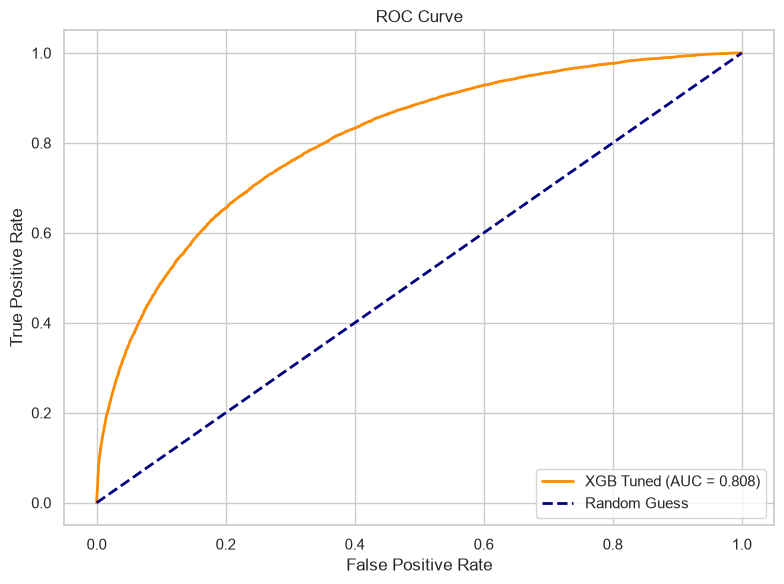

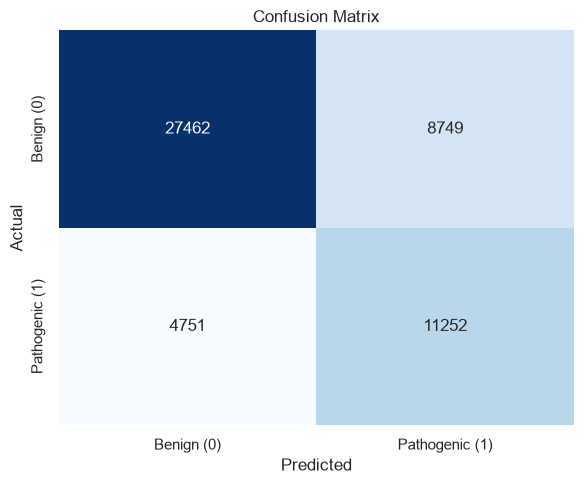

In [7]:
"""
Computes standard classification metrics on the holdout test set and generates 
ROC and Confusion Matrix visualizations for performance verification.
"""
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nOptimized XGB Classification Report:")
print(classification_report(y_test, y_pred))

# Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"XGB Tuned (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=300)
plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Benign (0)", "Pathogenic (1)"],
            yticklabels=["Benign (0)", "Pathogenic (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=300)
plt.show()

## Explainable AI (SHAP)

Generating SHAP feature attributions from scratch...
SHAP plot saved to ../images/shap_summary_plot.png


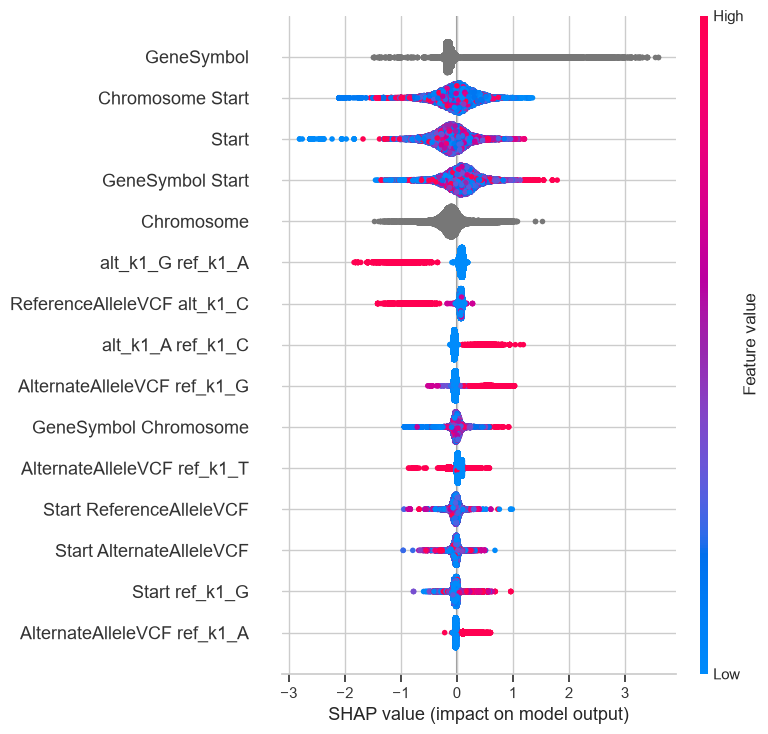

In [8]:
"""
Applies SHapley Additive exPlanations to interpret the directional impact and 
relative importance of biological drivers underlying model predictions.
"""
print("Generating SHAP feature attributions from scratch...")

# Subsample background dataset to optimize TreeExplainer computation overhead
explainer = shap.TreeExplainer(best_xgb, feature_perturbation="tree_path_dependent")
shap_values = explainer(X_test, check_additivity=False)

# Serialize SHAP values for subsequent analysis without recalculation
joblib.dump(shap_values, "../data/XGB_Optuna_shap_values.joblib")

# Decode features to ensure human-readable axis labels
X_test_decoded = X_test.copy()
for col in label_cols:
    if col in X_test_decoded.columns:
        X_test_decoded[col] = le_dict[col].inverse_transform(X_test[col].astype(int))

# Render and persist summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_decoded, max_display=15, show=False)
plt.savefig("../images/shap_summary_plot.png", bbox_inches='tight', dpi=300)
print("SHAP plot saved to ../images/shap_summary_plot.png")
plt.show()

## Clinical Application (VUS)

Analyzing Variants of Uncertain Significance (VUS)...


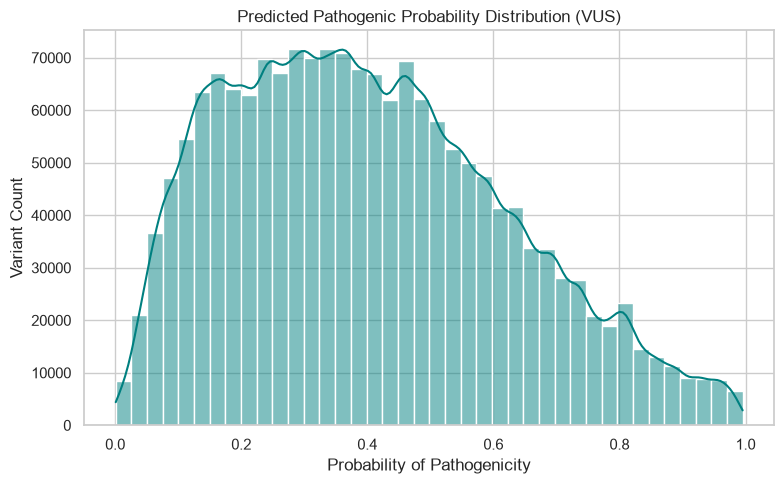

VUS Predictions successfully exported to ../data/results/

Top 10 High-Confidence Pathogenic VUS Candidates:


,VariationID,GeneSymbol,Chromosome,Pathogenic_Probability,Predicted_Label
335182,1331708,CFTR,7,0.995408,1
1497843,3491596,CFTR,7,0.995408,1
504014,1729579,CFTR,7,0.995408,1
504512,1734477,CFTR,7,0.995408,1
1497885,3491666,CFTR,7,0.995408,1
131556,632756,CFTR,7,0.995408,1
310129,1162237,CFTR,7,0.995408,1
310477,1163288,CFTR,7,0.995408,1
2861,53748,CFTR,7,0.995408,1
890269,2453653,CFTR,7,0.995408,1


In [9]:
"""
Applies the calibrated pipeline to the unclassified variant dataset to establish 
predictive probability baselines, exporting the distributions for clinical review.
"""
print("Analyzing Variants of Uncertain Significance (VUS)...")

vus_probs = best_xgb.predict_proba(X_vus)[:, 1]
vus_preds = best_xgb.predict(X_vus)

df_vus_results = X_vus.copy()
df_vus_results['VariationID'] = vus_variation_ids
df_vus_results['Pathogenic_Probability'] = vus_probs
df_vus_results['Predicted_Label'] = vus_preds

# Decode final results output
for col in label_cols:
    if col in df_vus_results.columns:
        df_vus_results[col] = le_dict[col].inverse_transform(X_vus[col].astype(int))

# Probability Distribution Visualization
plt.figure(figsize=(8, 5))
sns.histplot(vus_probs, bins=40, kde=True, color='teal')
plt.title("Predicted Pathogenic Probability Distribution (VUS)")
plt.xlabel("Probability of Pathogenicity")
plt.ylabel("Variant Count")
plt.tight_layout()
plt.savefig("../images/xgb_optuna_prob.png", dpi=300)
plt.show()

# Persist output arrays
df_vus_results.to_csv("../data/results/XGB_Optuna_VUS_Predictions.csv", index=False)
print("VUS Predictions successfully exported to ../data/results/")

# Data frame preview of high-confidence classifications
display_cols = ['VariationID', 'GeneSymbol', 'Chromosome', 'Pathogenic_Probability', 'Predicted_Label']
top_pathogenic = df_vus_results.sort_values(by='Pathogenic_Probability', ascending=False).head(10)
print("\nTop 10 High-Confidence Pathogenic VUS Candidates:")
display(top_pathogenic[display_cols])